# Train LightGB

### Imports

In [1]:
import pandas as pd
import numpy as np
from datetime import date
from pathlib import Path
import os
import joblib
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

%matplotlib inline
import matplotlib.pyplot as plt

import seaborn as sns

from add_features import add_features
from utils import TqdmCallback

### Global variables

In [2]:
root = Path(os.getcwd()).parent.parent
DATA_PATH = os.path.join(root, "data")
# DATASET_PATH = os.path.join(DATA_PATH, "main.csv")
DATASET_PATH = os.path.join(DATA_PATH, "main_preprocessed.csv")

TARGET = "NbPaxTotal"

LIMIT_DATE_TRAIN = pd.Timestamp("2025-12-31")
LIMIT_DATE_VALID = pd.Timestamp("2026-01-30")

### Load and prepare data

In [ ]:
df = pd.read_csv(DATASET_PATH)

### Remove the less important features.
# this feature_importance.csv dataset is obtained by training the model once with all the features . Here to save time, we first remove the useless features to test the model performances with the new set of features.
importance = pd.read_csv(os.path.join(DATA_PATH, 'feature_importance.csv'), encoding='utf-8')
col_to_rmv_list = importance["feature"].tail(500).tolist()
df = df.drop(columns=col_to_rmv_list)

df['LTScheduledDatetime'] = pd.to_datetime(df['LTScheduledDatetime'])

# df = add_features(df)
# df.to_csv("main_preprocessed.csv", index=False)

train_df = df[df['LTScheduledDatetime'] < LIMIT_DATE_TRAIN].copy()
valid_df = df[(df['LTScheduledDatetime'] >= LIMIT_DATE_TRAIN) & (df['LTScheduledDatetime'] < LIMIT_DATE_VALID)].copy()

print(f"Train set: {len(train_df)} rows / From {train_df['LTScheduledDatetime'].min()} to {train_df['LTScheduledDatetime'].max()}")
print(f"Valid set: {len(valid_df)} rows / From {valid_df['LTScheduledDatetime'].min()} to {valid_df['LTScheduledDatetime'].max()}")

X_train = train_df.drop(columns=[TARGET, "LTScheduledDatetime"])
y_train = train_df[TARGET]
X_valid = valid_df.drop(columns=[TARGET, "LTScheduledDatetime"])
y_valid = valid_df[TARGET]

for col in X_train.select_dtypes(include=['object']).columns:
    X_train[col] = X_train[col].astype('category')
    X_valid[col] = X_valid[col].astype('category')


C:\Users\bapti\AppData\Local\Temp\ipykernel_8388\2156354930.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATASET_PATH)


Train set: 286749 rows / From 2023-01-01 00:05:00 to 2025-12-30 23:55:00
Valid set: 7349 rows / From 2025-12-31 00:20:00 to 2026-01-29 23:45:00


### Training model

In [5]:
n_estimators = 10000

model = lgb.LGBMRegressor(
    objective="regression",      
    n_estimators=n_estimators,      
    learning_rate=0.01,
    num_leaves=255,               
    min_child_samples=5,
    feature_fraction=0.8,
    random_state=42,
    verbose=-1
)

tqdm_callback = TqdmCallback(total=n_estimators)
try:
    model.fit(
        X_train, y_train,         
        eval_set=[(X_valid, y_valid)], 
        eval_metric="mae",
        callbacks=[
            lgb.early_stopping(100),
            tqdm_callback 
        ]
    )
finally:
    tqdm_callback.pbar.close() 

Entraînement LightGBM:   0%|          | 1/10000 [00:24<67:34:46, 24.33s/it, mae=56.4399]

Training until validation scores don't improve for 100 rounds


Entraînement LightGBM:  10%|█         | 1026/10000 [14:34<1:52:42,  1.33it/s, mae=13.4092]

Early stopping, best iteration is:
[926]	valid_0's l1: 13.407	valid_0's l2: 476.18


Entraînement LightGBM:  10%|█         | 1026/10000 [14:36<2:07:47,  1.17it/s, mae=13.4092]


### Prediction and Evaluation

In [ ]:

joblib.dump(model, 'lgbm_regressor_NbPaxTotal_model.pkl')

predictions = model.predict(X_valid)
predictions = np.maximum(0, predictions)

mae = mean_absolute_error(y_valid, predictions)
r2 = r2_score(y_valid, predictions)
rmse = root_mean_squared_error(y_valid, predictions)

print(f"\n── RÉSULTATS FINAUX ──")
print(f"   MAE : {mae:.2f} passengers")    
print(f"   R²  : {r2:.4f}")
print(f"   RMSE : {rmse:.2f}")


── RÉSULTATS FINAUX ──
   MAE : 13.36 passengers
   R²  : 0.8933
   RMSE : 21.81


### Analysis

#### 1. Feature importance

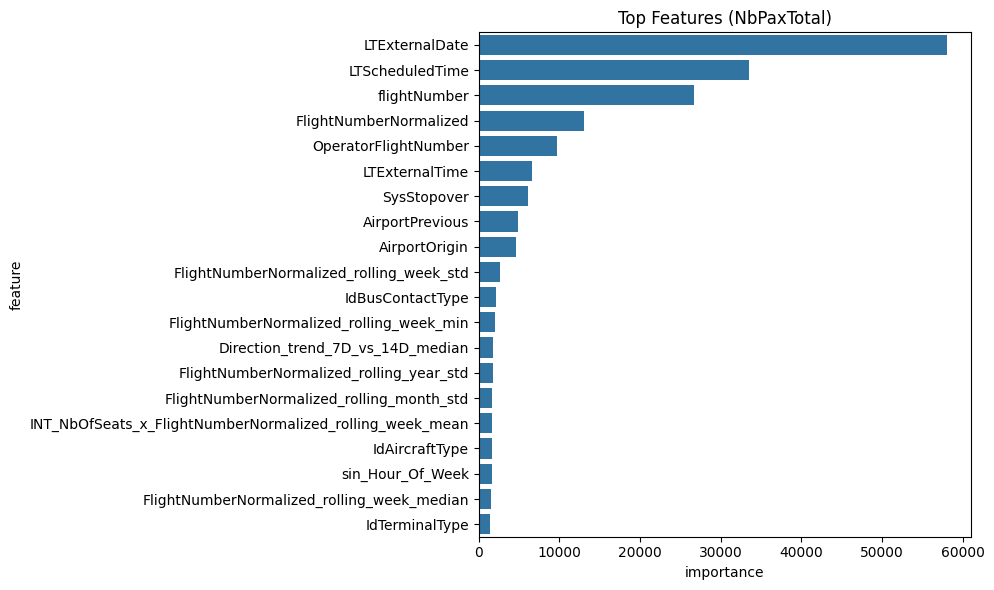

In [ ]:
importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)

importance.to_csv("features_importances_NbPaxTotal.csv", index=False)

plt.figure(figsize=(10, 6))
sns.barplot(x="importance", y="feature", data=importance.head(20))
plt.title("Top Features (NbPaxTotal)")
plt.tight_layout()
plt.show()

#### 2. Prediction VS Reality

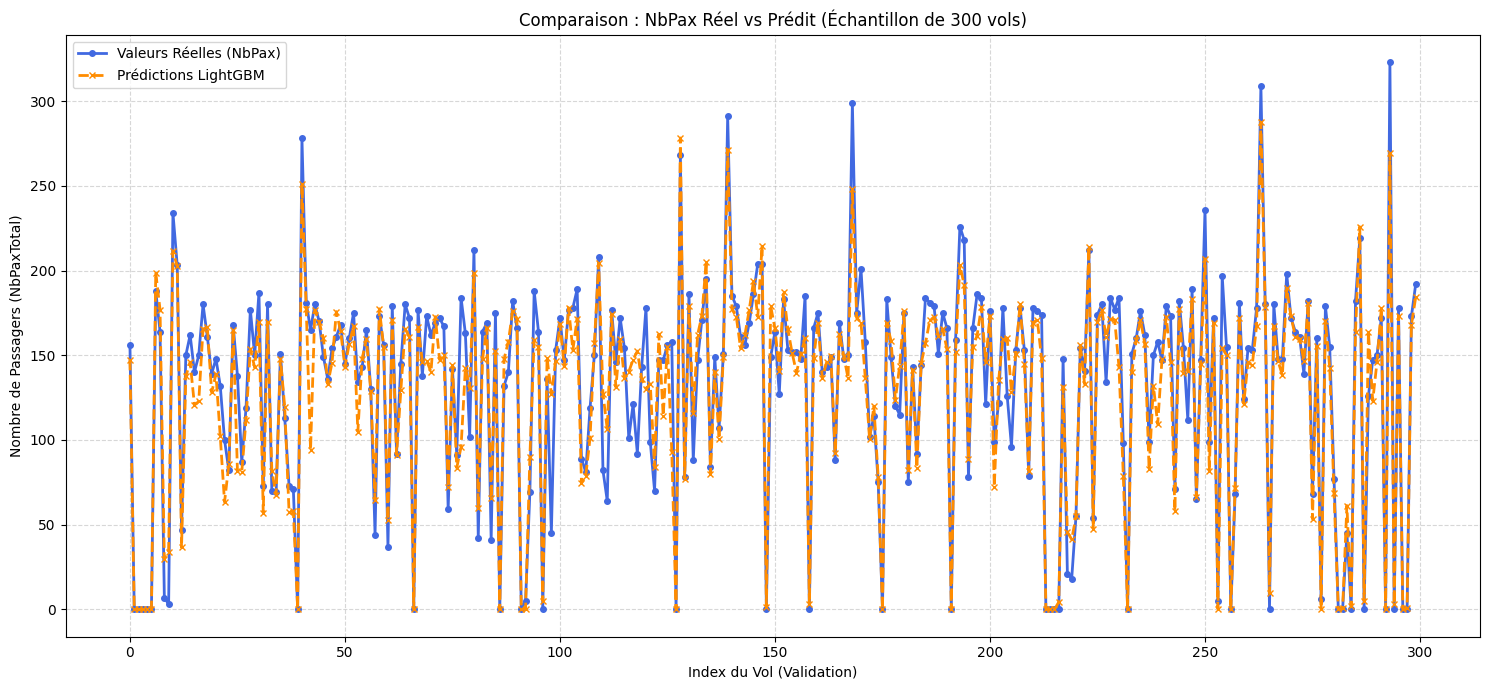

In [8]:
n_sample = 300 
plt.figure(figsize=(15, 7))
plt.plot(y_valid.values[:n_sample], label='Valeurs Réelles (NbPax)', color='royalblue', linewidth=2, marker='o', markersize=4)
plt.plot(predictions[:n_sample], label='Prédictions LightGBM', color='darkorange', linestyle='--', linewidth=2, marker='x', markersize=5)
plt.title(f'Comparaison : NbPax Réel vs Prédit (Échantillon de {n_sample} vols)')
plt.ylabel('Nombre de Passagers (NbPaxTotal)')
plt.xlabel('Index du Vol (Validation)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#### 3. TOP 10 Errors

In [10]:
analysis_df = valid_df.copy()
analysis_df['Predicted_NbPax'] = predictions
analysis_df['Abs_Error'] = np.abs(analysis_df[TARGET] - analysis_df['Predicted_NbPax'])
top_errors = analysis_df.sort_values(by='Abs_Error', ascending=False).head(10)

columns_to_show = ["FlightNumberNormalized",'LTScheduledDatetime', TARGET, 'Predicted_NbPax', "NbOfSeats", 'Abs_Error']

top_errors_display = top_errors[columns_to_show].copy()
top_errors_display['Predicted_NbPax'] = top_errors_display['Predicted_NbPax'].round(1)
top_errors_display['Abs_Error'] = top_errors_display['Abs_Error'].round(1)

print(top_errors_display.to_string(index=False))

FlightNumberNormalized LTScheduledDatetime  NbPaxTotal  Predicted_NbPax  NbOfSeats  Abs_Error
              WMT06061 2026-01-07 11:30:00         0.0            195.5      239.0      195.5
              EJU08435 2026-01-04 18:50:00         0.0            171.7      180.0      171.7
              EZY04780 2026-01-06 00:30:00         0.0            171.3      186.0      171.3
              BAW00363 2026-01-03 21:45:00       170.0              0.0      180.0      170.0
              VOE02533 2026-01-06 00:45:00       171.0              2.3      180.0      168.7
              NSZ09713 2026-01-17 16:15:00         0.0            163.5      189.0      163.5
              WZZ04394 2025-12-31 19:55:00        57.0            219.0      239.0      162.0
              EJU04307 2026-01-04 14:35:00         0.0            158.4      180.0      158.4
              TVF03382 2026-01-18 06:00:00         0.0            157.4      189.0      157.4
              DLH01076 2026-01-03 14:15:00       162.0      